# Test 1 Machine learning (Question 2)
### Muzaffar Izamuddin bin Daud - P166246

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
%matplotlib inline

In [6]:
df = pd.read_csv("Question_2.csv")

In [11]:
X = df.drop(['Appliances','date','lights'], axis=1).astype('float64')
y = df['Appliances'].values

In [12]:
df.head()

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T8,RH_8,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint
0,11/1/2016 17:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,18.2,48.900000,17.033333,45.53,6.60,733.5,92.0,7.000000,63.000000,5.3
1,11/1/2016 17:10,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,18.2,48.863333,17.066667,45.56,6.48,733.6,92.0,6.666667,59.166667,5.2
2,11/1/2016 17:20,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,18.2,48.730000,17.000000,45.50,6.37,733.7,92.0,6.333333,55.333333,5.1
3,11/1/2016 17:30,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,18.1,48.590000,17.000000,45.40,6.25,733.8,92.0,6.000000,51.500000,5.0
4,11/1/2016 17:40,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,18.1,48.590000,17.000000,45.40,6.13,733.9,92.0,5.666667,47.666667,4.9


In [13]:
X.head()

,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,RH_5,...,T8,RH_8,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint
0,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,45.566667,17.166667,55.20,...,18.2,48.900000,17.033333,45.53,6.60,733.5,92.0,7.000000,63.000000,5.3
1,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,45.992500,17.166667,55.20,...,18.2,48.863333,17.066667,45.56,6.48,733.6,92.0,6.666667,59.166667,5.2
2,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,45.890000,17.166667,55.09,...,18.2,48.730000,17.000000,45.50,6.37,733.7,92.0,6.333333,55.333333,5.1
3,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,45.723333,17.166667,55.09,...,18.1,48.590000,17.000000,45.40,6.25,733.8,92.0,6.000000,51.500000,5.0
4,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,45.530000,17.200000,55.09,...,18.1,48.590000,17.000000,45.40,6.13,733.9,92.0,5.666667,47.666667,4.9


In [15]:
y

array([ 60,  60,  50, ..., 270, 420, 430], shape=(19735,))

Cumulative variance explained:
  PC1: 38.8%
  PC2: 68.2%
  PC3: 75.8%
  PC4: 80.2%
  PC5: 84.2%
  PC6: 88.2%
  PC7: 90.5%
  PC8: 92.7%
  PC9: 94.3%
  PC10: 95.4%
  PC11: 96.2%
  PC12: 96.8%
  PC13: 97.4%
  PC14: 97.9%
  PC15: 98.3%
  PC16: 98.7%
  PC17: 99.0%
  PC18: 99.3%
  PC19: 99.5%
  PC20: 99.7%
  PC21: 99.8%
  PC22: 99.9%
  PC23: 100.0%
  PC24: 100.0%

Best number of PCs: 24, CV-MSE: 8997.54


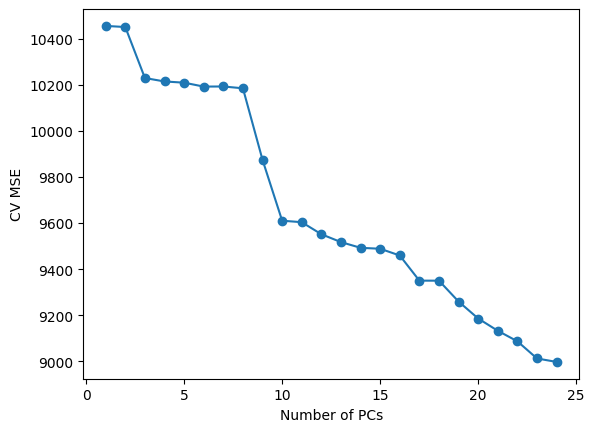

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import scale
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, KFold

# PCA (Question 2 a)
pca = PCA()
X_reduced = pca.fit_transform(scale(X))

cum_var = np.cumsum(np.round(pca.explained_variance_ratio_, 4) * 100)
print("Cumulative variance explained:")
for i, v in enumerate(cum_var, 1):
    print(f"  PC{i}: {v:.1f}%")

# PCR via CV (Question 2 b)
kf = KFold(n_splits=10, shuffle=True, random_state=1)
lr = LinearRegression()
mse = []
for i in range(1, X_reduced.shape[1] + 1):
    scores = cross_val_score(lr, X_reduced[:, :i], y,
                             scoring='neg_mean_squared_error', cv=kf)
    mse.append(-scores.mean())

best_m = np.argmin(mse) + 1
print(f"\nBest number of PCs: {best_m}, CV-MSE: {mse[best_m-1]:.2f}")

plt.plot(range(1, len(mse)+1), mse, '-o')
plt.xlabel('Number of PCs'); plt.ylabel('CV MSE'); plt.show()

The PCR MSE with increasing number of PCs did not have a clear elbow, by taking the lowest CV-MSE we arrived at 24 Principal components with a CV MSE of 8997.54.

In [19]:
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Scale using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# Find best alpha with RidgeCV
rcv = RidgeCV(alphas=np.linspace(0.01, 100, 1000), cv=10) #Cross validation of 10 used here as asked in question
rcv.fit(X_train, y_train)
print("Best alpha:", rcv.alpha_)

# Refit Ridge with best alpha and evaluate
ridge = Ridge(alpha=rcv.alpha_)
ridge.fit(X_train, y_train)

mse = mean_squared_error(y_test, ridge.predict(X_test))
print(f"Test MSE: {mse:.2f}")

# Top 3 coefficients
coef_series = pd.Series(ridge.coef_, index=X.columns).abs().sort_values(ascending=False)
print("Top 3 predictors:\n", coef_series.head(3))

Best alpha: 4.213783783783783
Test MSE: 8766.06
Top 3 predictors:
 RH_1     64.296475
RH_2     54.906202
T_out    54.797550
dtype: float64


It was found that Principal Component regression was less effective using this dataset as the MSE only reached the lowest level of 8997.54 at 24 principal components while Ridge regression was able to achieve a better mean squared error of 8766.06 at a tuned alpha of 4.213 (achieved using a cross validation of 10)

Ridge regression also give us clear understanding on which datapoint is most important as the top 3 predictors are RH_1 , RH_2 and T_out. PCR can also do this but will need to map back the principal components to its original features. 